In [1]:
import pandas as pd

def load_data(filepath):
    """
    Load features X and labels y_1, y_2 from a CSV file.

    Parameters
    ----------
    filepath : str
        Path to the CSV file.

    Returns
    -------
    X : pandas.DataFrame
        Feature matrix (all columns except last two).
    y_1 : pandas.Series
        Label from the second-to-last column.
    y_2 : pandas.Series
        Label from the last column.
    """
    df = pd.read_csv(filepath)

    # Features: all columns except last two
    X = df.iloc[:, :-2]

    # Labels
    y_1 = df.iloc[:, -2]
    y_2 = df.iloc[:, -1]

    return X, y_1, y_2

In [ ]:
# Load data
X, y_1, y_2 = load_data("/Users/aschuetz/Documents/Analysis/bbh/resolve/examples/binary-black-hole/run_hcattnnp/predictions.csv")





In [4]:
# Run UMAP
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)



/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/resolve/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/resolve/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [40]:
mask0_1 = (y_1 == 0)
mask1_1 = (y_1 == 1)
mask0_2 = (y_2 < 0.98)
mask1_2 = (y_2 >= 0.98)
mask0_3 = (y_1 == 0)
mask1_3 = (y_1 == 1)
mask2_3 = (y_1 == 0) & (y_2 > 0.97)

Text(0.5, 1.0, 'UMAP projection colored by y_2')

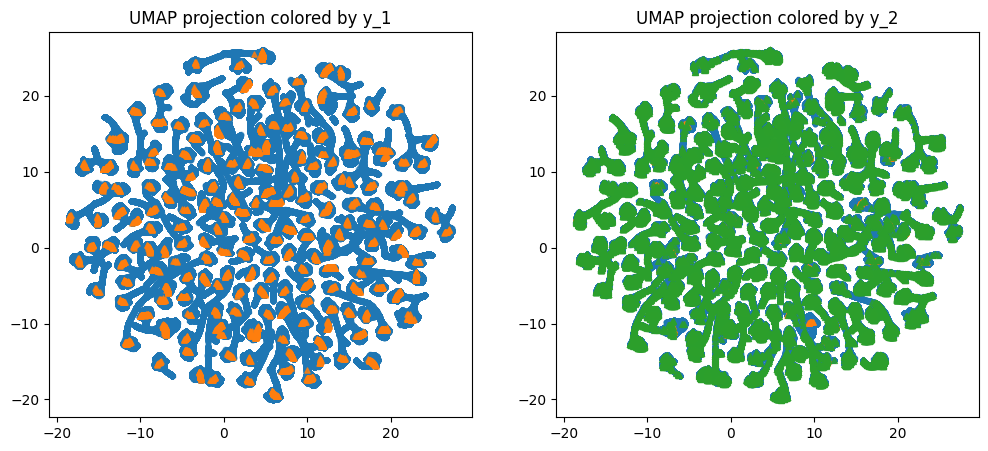

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
# Example visualization for y_1
axes[0].scatter(X_umap[mask0_1, 0], X_umap[mask0_1, 1],
            s=10, alpha=0.5, marker='o', label='Class 0', zorder=1)
axes[0].scatter(X_umap[mask1_1, 0], X_umap[mask1_1, 1],
            s=14, alpha=0.8, marker='^', label='Class 1', zorder=2)
axes[0].set_title("UMAP projection colored by y_1")

# Example visualization for y_1
axes[1].scatter(X_umap[mask0_3, 0], X_umap[mask0_3, 1],
            s=10, alpha=0.5, marker='o', label='Class 0', zorder=1)
axes[1].scatter(X_umap[mask1_3, 0], X_umap[mask1_3, 1],
            s=14, alpha=0.8, marker='^', label='Class 1', zorder=2)
axes[1].scatter(X_umap[mask2_3, 0], X_umap[mask2_3, 1],
            s=18, alpha=0.8, marker='^', label='Class 1', zorder=3)
axes[1].set_title("UMAP projection colored by y_2")


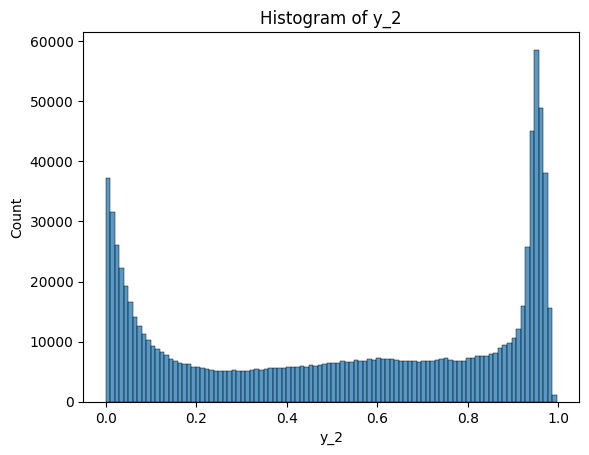

In [21]:
import seaborn as sns

sns.histplot(y_2, bins=100, kde=False)
plt.xlabel("y_2")
plt.title("Histogram of y_2")
plt.show()